# 12 - Bitstring-Visualisierung: Idealer Simulator vs. Noise Model vs. Hardware

Dieses Notebook illustriert den Einfluss von Quantenrauschen anhand eines Bell-Zustands.
Derselbe Schaltkreis wird dreimal ausgeführt:
1. Idealer AerSimulator (kein Rauschen)
2. AerSimulator mit Noise Model (simuliertes Rauschen)
3. IBM Hardware (ibm_kingston) - gespeicherte Ergebnisse

**Erwartung:**
- Ideal: nur `00` und `11` (perfekte Bell-Korrelation)
- Noise/Hardware: zusätzlich `01` und `10` durch Dekohärenz und Gate-Fehler

## Imports

In [1]:
from qiskit import QuantumCircuit  # transpile kann weg
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
from qiskit_ibm_runtime import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## Bell-Zustand Schaltkreis

Der Bell-Zustand $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ wird durch einen Hadamard-Gate auf Qubit 0 und ein CNOT-Gate erzeugt.

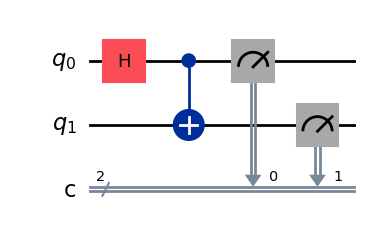

In [2]:
# Bell-Zustand Schaltkreis
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

qc.draw('mpl')

## 1. Idealer Simulator (kein Rauschen)

In [4]:
SHOTS = 1024
OPTIMIZATION_LEVEL = 1  # anpassbar für späteren Vergleich

# Idealer AerSimulator
ideal_backend = AerSimulator()
pm_ideal = generate_preset_pass_manager(
    optimization_level=OPTIMIZATION_LEVEL,
    backend=ideal_backend
)
qc_t = pm_ideal.run(qc)

print(f"Circuit depth (level {OPTIMIZATION_LEVEL}):", qc_t.depth())
print("Gate counts:", qc_t.count_ops())

sampler = Sampler(ideal_backend)
job = sampler.run([qc_t], shots=SHOTS)
result = job.result()
counts_ideal = result[0].data.c.get_counts()

print("Idealer Simulator:", counts_ideal)

Circuit depth (level 1): 3
Gate counts: OrderedDict([('measure', 2), ('h', 1), ('cx', 1)])
Idealer Simulator: {'11': 495, '00': 529}


## 2. Noise Model Simulator

Ein einfaches Noise Model mit Depolarisierungsfehlern simuliert reale Hardware-Eigenschaften.

In [5]:
# Noise Model aufbauen
noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1)
error_2q = depolarizing_error(0.01, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'u1', 'u2', 'u3'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

# Noisy Simulator
noisy_backend = AerSimulator(noise_model=noise_model)
pm_noisy = generate_preset_pass_manager(
    optimization_level=OPTIMIZATION_LEVEL,
    backend=noisy_backend
)
qc_t_noisy = pm_noisy.run(qc)

sampler_noisy = Sampler(noisy_backend)
job_noisy = sampler_noisy.run([qc_t_noisy], shots=SHOTS)
result_noisy = job_noisy.result()
counts_noise = result_noisy[0].data.c.get_counts()

print("Noise Model Simulator:", counts_noise)

Noise Model Simulator: {'00': 511, '11': 506, '10': 3, '01': 4}


## 3. IBM Hardware - ibm_kingston (gespeicherte Ergebnisse)

Die Hardware-Ergebnisse stammen aus einem früheren Job auf `ibm_kingston`.
Job ID: `d7nsan497osc73dsfbr0`

In [6]:
# Gespeicherte Hardware-Ergebnisse (ibm_kingston, 1024 shots)
counts_hardware = {'00': 499, '11': 514, '10': 7, '01': 4}

print("IBM Hardware (ibm_kingston):", counts_hardware)
fehlerrate = (counts_hardware.get('01', 0) + counts_hardware.get('10', 0)) / SHOTS * 100
print(f"Fehlerrate: {fehlerrate:.1f}%")

IBM Hardware (ibm_kingston): {'00': 499, '11': 514, '10': 7, '01': 4}
Fehlerrate: 1.1%


## Visualisierung: Drei Balkendiagramme im Vergleich

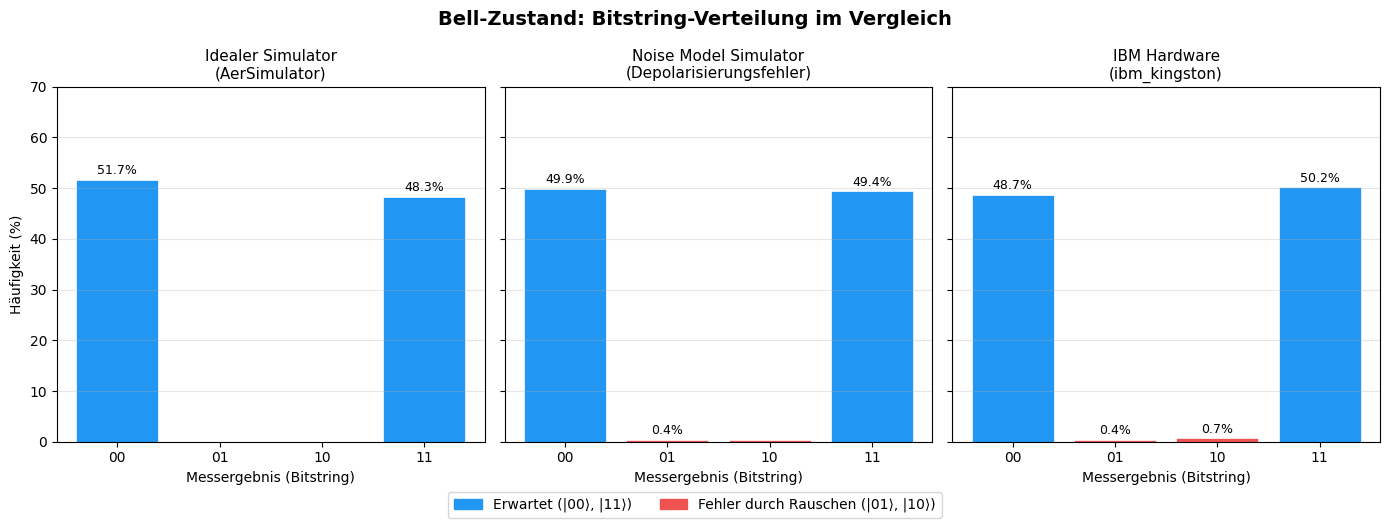

Grafik gespeichert: bitstring_vergleich.png


In [7]:
def normalize_counts(counts, shots=SHOTS):
    """Alle vier Bitstings sicherstellen, fehlende mit 0 auffüllen."""
    all_keys = ['00', '01', '10', '11']
    return {k: counts.get(k, 0) / shots * 100 for k in all_keys}

data_ideal   = normalize_counts(counts_ideal)
data_noise   = normalize_counts(counts_noise)
data_hw      = normalize_counts(counts_hardware)

labels = ['00', '01', '10', '11']
x = np.arange(len(labels))
colors_expected = ['#2196F3', '#EF5350', '#EF5350', '#2196F3']  # Blau=erwartet, Rot=Fehler

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('Bell-Zustand: Bitstring-Verteilung im Vergleich', fontsize=14, fontweight='bold')

datasets = [
    (data_ideal,  'Idealer Simulator\n(AerSimulator)'),
    (data_noise,  'Noise Model Simulator\n(Depolarisierungsfehler)'),
    (data_hw,     'IBM Hardware\n(ibm_kingston)'),
]

for ax, (data, title) in zip(axes, datasets):
    values = [data[k] for k in labels]
    bars = ax.bar(labels, values, color=colors_expected, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Messergebnis (Bitstring)')
    ax.set_ylim(0, 70)
    ax.grid(axis='y', alpha=0.3)
    # Prozentwerte über Balken
    for bar, val in zip(bars, values):
        if val > 0.3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel('Häufigkeit (%)')

# Legende
patch_expected = mpatches.Patch(color='#2196F3', label='Erwartet (|00⟩, |11⟩)')
patch_error    = mpatches.Patch(color='#EF5350', label='Fehler durch Rauschen (|01⟩, |10⟩)')
fig.legend(handles=[patch_expected, patch_error], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.savefig('bitstring_vergleich.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik gespeichert: bitstring_vergleich.png")

## Interpretation

| Ausführung | `00` | `01` | `10` | `11` | Fehlerrate |
|---|---|---|---|---|---|
| Idealer Simulator | ~50% | 0% | 0% | ~50% | **0%** |
| Noise Model | ~50% | >0% | >0% | ~50% | **gering** |
| IBM Hardware | ~49% | ~0.4% | ~0.7% | ~50% | **~1.1%** |

**Fazit:** Der ideale Simulator erzeugt ausschließlich die erwarteten Bell-Zustände `|00⟩` und `|11⟩`. 
Auf echter Hardware treten durch **Dekohärenz** und **Gate-Fehler** auch die Zustände `|01⟩` und `|10⟩` auf - 
dies ist ein direkter empirischer Beleg für Quantenrauschen auf NISQ-Geräten.